In [9]:
#importing libraries
import ast 
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [11]:

#filtering the data to only Data Analyst from the US
df_DA_US = df[(df['job_title_short']== "Data Analyst") & (df['job_country']== "United States")].copy()

#dropping nan values
df_DA_US= df_DA_US.dropna(subset=['salary_year_avg'])

In [13]:
df_DA_US= df_DA_US.explode('job_skills')

In [23]:
df_DA_US_group= df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

In [34]:
top_pay= df_DA_US_group.sort_values('median', ascending=False).head(10)

top_skills= df_DA_US_group.sort_values('count', ascending=False).head(10).sort_values('median', ascending=False)

top_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


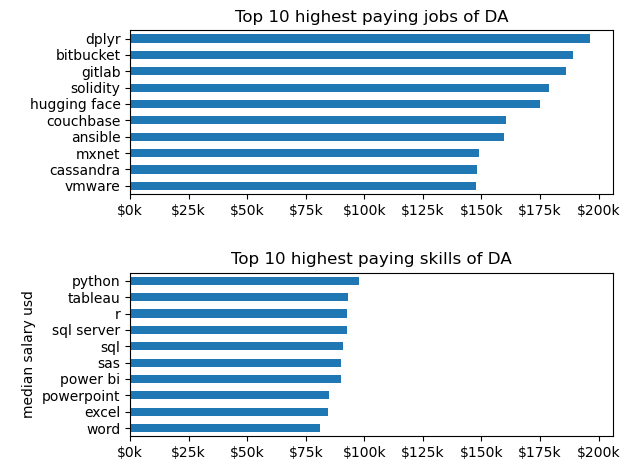

In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter # Added required import

fig, ax = plt.subplots(2, 1)

# --- Top Plot (ax[0]) ---
top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)

ax[0].set_title('Top 10 highest paying jobs of DA')
ax[0].set_ylabel(' ')
ax[0].set_xlabel(' ') # Removed trailing comma

# Fixed: Target ax[0].xaxis, use correct capitalization, and closed both parentheses
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# --- Bottom Plot (ax[1]) ---
top_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)

ax[1].set_title('Top 10 highest paying skills of DA')
ax[1].set_ylabel('median salary usd')
ax[1].set_xlabel('') # Removed trailing comma

# Fixed: Target ax[1].xaxis, use correct capitalization, and closed both parentheses
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# --- Final Adjustments ---
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()